In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
hotspots = gpd.read_file("data/hotspots_filtered.geojson")
hotspots

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry
0,42.36865,-7.10923,338.51,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,294.59,4.62,N,0,POINT (-7.10923 42.36865)
1,42.36788,-7.10464,316.48,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,294.94,1.69,N,0,POINT (-7.10464 42.36788)
2,42.36538,-7.11030,338.29,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,296.74,7.84,N,0,POINT (-7.1103 42.36538)
3,42.36460,-7.10568,353.17,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,311.85,9.92,N,0,POINT (-7.10568 42.3646)
4,42.36383,-7.10108,323.26,0.39,0.36,2025-08-15,0232,N,VIIRS,n,2,293.39,9.92,N,0,POINT (-7.10108 42.36383)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,42.52095,-7.11022,367.00,0.55,0.51,2025-08-20,1402,N,VIIRS,h,2,328.44,92.18,D,0,POINT (-7.11022 42.52095)
1018,42.52208,-7.09335,335.03,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,281.72,6.24,D,0,POINT (-7.09335 42.52208)
1019,42.52131,-7.10489,355.47,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,299.98,92.18,D,0,POINT (-7.10489 42.52131)
1020,42.52609,-7.10497,345.23,0.55,0.51,2025-08-20,1402,N,VIIRS,n,2,286.11,11.72,D,0,POINT (-7.10497 42.52609)


<Axes: >

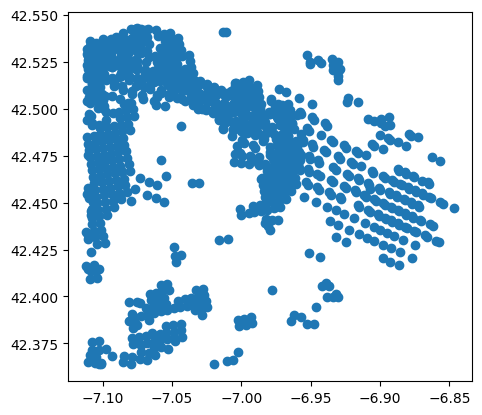

In [4]:
hotspots.plot()

In [7]:
dates = hotspots.ACQ_DATE.unique()
dates

<DatetimeArray>
['2025-08-15 00:00:00', '2025-08-16 00:00:00', '2025-08-17 00:00:00',
 '2025-08-18 00:00:00', '2025-08-19 00:00:00', '2025-08-20 00:00:00']
Length: 6, dtype: datetime64[ms]

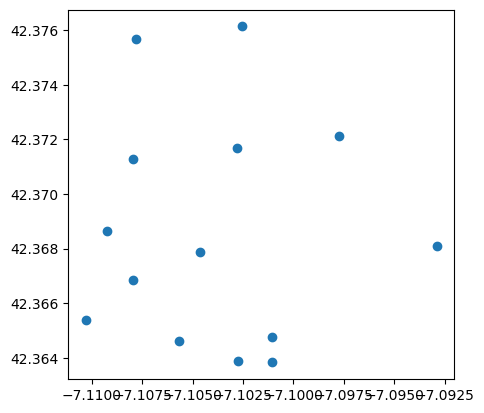

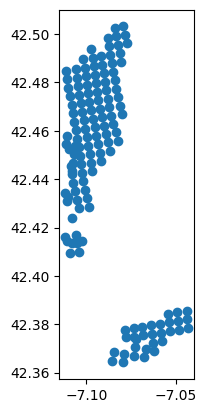

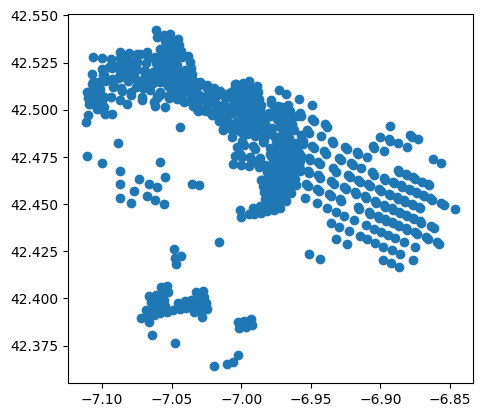

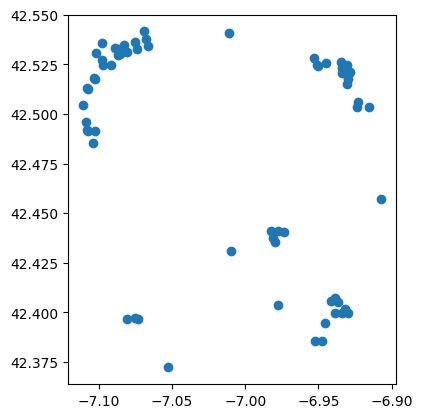

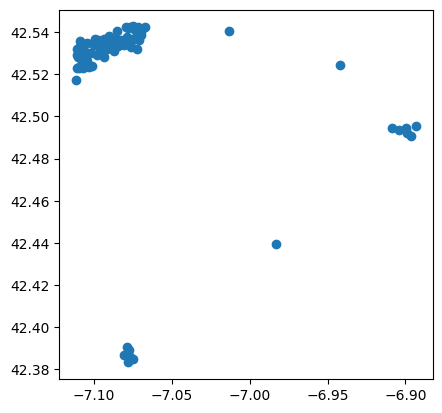

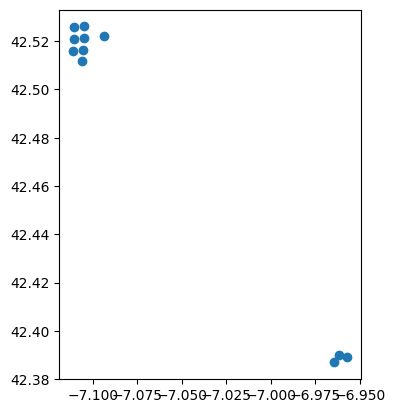

In [10]:
for date in dates:
    hotspots_date = hotspots[hotspots.ACQ_DATE == date]
    hotspots_date.plot()
    plt.show()


Date: 2025-08-15 00:00:00  →  Polygon count: 1


/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


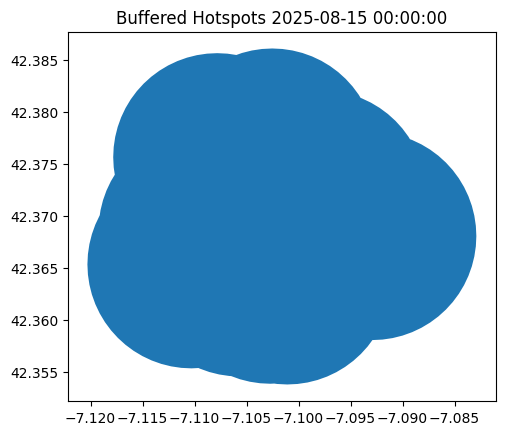

Date: 2025-08-16 00:00:00  →  Polygon count: 2


/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


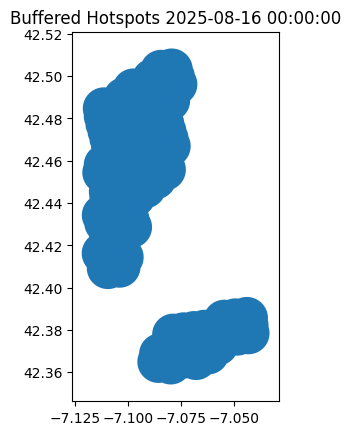

Date: 2025-08-17 00:00:00  →  Polygon count: 4


/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


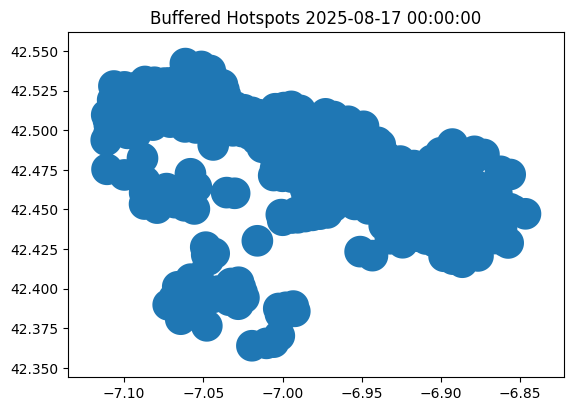

/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


Date: 2025-08-18 00:00:00  →  Polygon count: 10


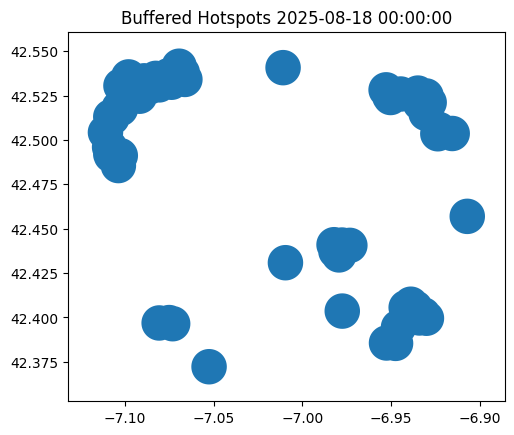

/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


Date: 2025-08-19 00:00:00  →  Polygon count: 6


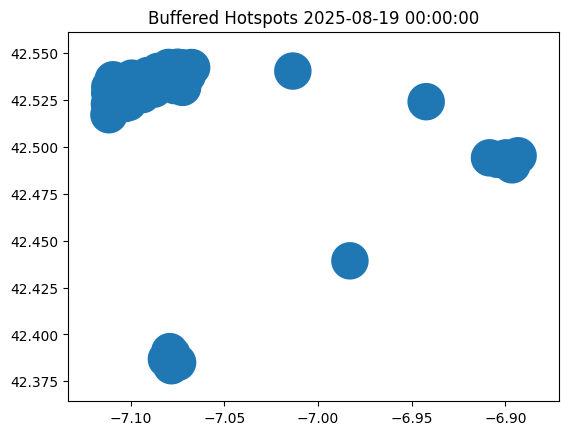

/tmp/ipykernel_31073/2513866592.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffered = hotspots_date.geometry.buffer(buffer_radius)


Date: 2025-08-20 00:00:00  →  Polygon count: 2


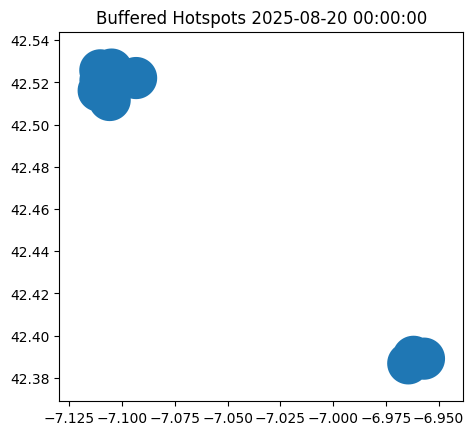

/home/juan/Desktop/grand-marathon-mvp/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [14]:
from shapely.ops import unary_union
from shapely.geometry import Polygon, MultiPolygon
import pandas as pd

buffer_radius = 0.01  # adjust as needed (~200m if degrees)

all_rows = []  # Will store each multipolygon part as a separate row

for date in dates:
    # Filter hotspots for this date
    hotspots_date = hotspots[hotspots.ACQ_DATE == date]

    # Buffer all points to create small areas around each point
    buffered = hotspots_date.geometry.buffer(buffer_radius)

    # Join (union) all the buffered polygons (merging overlapping/close ones)
    multipolygon = unary_union(buffered)

    # Ensure we have a MultiPolygon (even if only one polygon)
    if isinstance(multipolygon, Polygon):
        polygons = [multipolygon]
    elif isinstance(multipolygon, MultiPolygon):
        polygons = list(multipolygon.geoms)
    else:
        polygons = []

    print(f"Date: {date}  →  Polygon count: {len(polygons)}")

    # Save individual polygons for this date as rows
    for poly in polygons:
        all_rows.append({"date": date, "geometry": poly})

    # Optionally (commented out): still plot per date
    gdf = gpd.GeoDataFrame(geometry=polygons)
    gdf.plot()
    plt.title(f"Buffered Hotspots {date}")
    plt.show()

# Create a GeoDataFrame with all polygons (across all dates)
final_gdf = gpd.GeoDataFrame(all_rows)

# Save the final geojson with all multipolygon-parts as separate features
final_gdf.to_file("data/hotspots_buffered.geojson", driver="GeoJSON")